**Calling important files and libraries**

In [1]:
from Bio import SeqIO

# To open and read the FASTA file
record = SeqIO.read("NM_000518.5.fasta", "fasta")

print("ID:", record.id)
print("Description:", record.description)
print("Sequence:")

print(record.id)
print(record.seq)

ID: NM_000518.5
Description: NM_000518.5 Homo sapiens hemoglobin subunit beta (HBB), mRNA
Sequence:
NM_000518.5
ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGGGGATCTGTCCACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGTGCCTTTAGTGATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACTGTGACAAGCTGCACGTGGATCCTGAGAACTTCAGGCTCCTGGGCAACGTGCTGGTCTGTGTGCTGGCCCATCACTTTGGCAAAGAATTCACCCCACCAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGTGTGGCTAATGCCCTGGCCCACAAGTATCACTAAGCTCGCTTTCTTGCTGTCCAATTTCTATTAAAGGTTCCTTTGTTCCCTAAGTCCAACTACTAAACTGGGGGATATTATGAAGGGCCTTGAGCATCTGGATTCTGCCTAATAAAAAACATTTATTTTCATTGCAA


In [2]:
from Bio.Blast import NCBIWWW
from Bio import SeqIO

**Storing sequence as string and getting first 100 bases**

In [3]:
from Bio import SeqIO

# Read the FASTA file
record = SeqIO.read("NM_000518.5.fasta", "fasta")

# To store the sequence as a string
sequence = str(record.seq)

print("Sequence length:", len(sequence))
print(sequence[:100])  # to see first 100 bases

Sequence length: 628
ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGG


**To run nucleotide blastn**

In [17]:
from Bio.Blast import NCBIWWW

# To run BLAST (blastn for nucleotide sequences)
result_handle = NCBIWWW.qblast(
    program="blastn",
    database="nt",
    sequence=sequence
)

**To store the blast result as xml**

In [18]:

with open("blast_results.xml", "w") as out_handle:
    out_handle.write(result_handle.read())


**To print the BLAST result**

In [19]:
from Bio.Blast import NCBIXML

with open("blast_results.xml") as result_handle:
    blast_record = NCBIXML.read(result_handle)

for alignment in blast_record.alignments[:5]:  # Top 5 hits
    print("Title:", alignment.title)
    print("Length:", alignment.length)

    for hsp in alignment.hsps[:1]:  # First HSP
        print("Score:", hsp.score)
        print("E-value:", hsp.expect)
        print("Identities:", hsp.identities)
        print("Percent identity:", round((hsp.identities / hsp.align_length) * 100, 2), "%")
        print("-" * 50)

Title: gi|1401724401|ref|NM_000518.5| Homo sapiens hemoglobin subunit beta (HBB), mRNA
Length: 628
Score: 1256.0
E-value: 0.0
Identities: 628
Percent identity: 100.0 %
--------------------------------------------------
Title: gi|2468480781|ref|XM_508242.5| PREDICTED: Pan troglodytes hemoglobin subunit beta (HBB), mRNA
Length: 639
Score: 1251.0
E-value: 0.0
Identities: 627
Percent identity: 99.84 %
--------------------------------------------------
Title: gi|2694496772|ref|XM_003819029.5| PREDICTED: Pan paniscus hemoglobin subunit beta (LOC100976465), mRNA
Length: 643
Score: 1246.0
E-value: 0.0
Identities: 626
Percent identity: 99.68 %
--------------------------------------------------
Title: gi|13937928|gb|BC007075.1| Homo sapiens hemoglobin, beta, mRNA (cDNA clone MGC:14540 IMAGE:4292125), complete cds
Length: 658
Score: 1239.0
E-value: 0.0
Identities: 624
Percent identity: 99.52 %
--------------------------------------------------
Title: gi|29436|emb|V00497.1| Human messenger RNA for

**Running BLAST in comparison to one outlier organism**

**in this case mouse**

In [20]:
from Bio.Blast import NCBIWWW
from Bio import SeqIO

# Reading FASTA file
record = SeqIO.read("NM_000518.5.fasta", "fasta")
sequence = str(record.seq)

# doing BLAST against an outlier group: mouse
result_handle = NCBIWWW.qblast(
    program="blastn",
    database="nt",
    sequence=sequence,
    entrez_query="Mus musculus[Organism]"
)

# Saving the results as xml file
with open("mouse_outlier_blast.xml", "w") as out_file:
    out_file.write(result_handle.read())

**printing of Blast result in case of mouse**

In [21]:
from Bio.Blast import NCBIXML

with open("mouse_outlier_blast.xml") as result_handle:
    blast_record = NCBIXML.read(result_handle)

for alignment in blast_record.alignments[:5]:
    print("Title:", alignment.title)
    print("Length:", alignment.length)

    hsp = alignment.hsps[0]
    print("Score:", hsp.score)
    print("E-value:", hsp.expect)
    print("Identities:", hsp.identities)
    print("Percent identity:", round((hsp.identities / hsp.align_length) * 100, 2), "%")
    print("-" * 50)

Title: gi|12846885|dbj|AK011033.1| Mus musculus 13 days embryo liver cDNA, RIKEN full-length enriched library, clone:2510031C09 product:hemoglobin, beta adult major chain, full insert sequence
Length: 627
Score: 585.0
E-value: 4.26913e-147
Identities: 502
Percent identity: 79.3 %
--------------------------------------------------
Title: gi|12849365|dbj|AK012551.1| Mus musculus 11 days embryo whole body cDNA, RIKEN full-length enriched library, clone:2700082N11 product:hemoglobin, beta adult major chain, full insert sequence
Length: 646
Score: 584.0
E-value: 4.26913e-147
Identities: 500
Percent identity: 79.37 %
--------------------------------------------------
Title: gi|12832344|dbj|AK002394.1| Mus musculus adult male kidney cDNA, RIKEN full-length enriched library, clone:0610009G19 product:hemoglobin, beta adult major chain, full insert sequence >gi|12838093|dbj|AK005496.1| Mus musculus adult female placenta cDNA, RIKEN full-length enriched library, clone:1600019I13 product:hemoglobi

In [22]:
'''
entrez_query="Gallus gallus[Organism]"   # chicken
entrez_query="Danio rerio[Organism]"     # zebrafish
entrez_query="Xenopus laevis[Organism]"  # frog
'''

'\nentrez_query="Gallus gallus[Organism]"   # chicken\nentrez_query="Danio rerio[Organism]"     # zebrafish\nentrez_query="Xenopus laevis[Organism]"  # frog\n'

# Multiple sequence Alignment

**collecting the sequences for alignment**

Human HBB (NM_000518.5)

Chimpanzee HBB

Bonobo HBB

Mouse HBB (outlier)

In [23]:
sequence = str(record.seq)
human_sequence = sequence  # your NM_000518.5 sequence

chimp_sequence = "PASTE_CHIMP_SEQUENCE_HERE"
bonobo_sequence = "PASTE_BONOBO_SEQUENCE_HERE"
mouse_sequence = "PASTE_MOUSE_SEQUENCE_HERE"

**Saving them in one fasta file called hbb_sequences.fasta**

In [24]:
with open("hbb_sequences.fasta", "w") as f:
    f.write(">Human_HBB\n")
    f.write(human_sequence + "\n")

    f.write(">Chimp_HBB\n")
    f.write(chimp_sequence + "\n")

    f.write(">Bonobo_HBB\n")
    f.write(bonobo_sequence + "\n")

    f.write(">Mouse_HBB\n")
    f.write(mouse_sequence + "\n")

In [25]:
from Bio.Blast import NCBIXML

with open("blast_results.xml") as result_handle:
    blast_record = NCBIXML.read(result_handle)

for alignment in blast_record.alignments[:3]:
    print(alignment.accession)

NM_000518
XM_508242
XM_003819029


In [26]:
with open("mouse_outlier_blast.xml") as result_handle:
    mouse_record = NCBIXML.read(result_handle)

for alignment in mouse_record.alignments[:3]:
    print(alignment.accession)

AK011033
AK012551
AK002394


In [27]:
mouse_accession = mouse_record.alignments[0].accession
print(mouse_accession)

AK011033


In [28]:
accessions = [
    "NM_000518.5",      # Human
    "XM_508242.5",      # Chimpanzee
    "XM_003819029.5",   # Bonobo
    "AK011033.1"        # Mouse outgroup
]

**Downloading actual fasta sequence using the accession numbers**

In [29]:
from Bio import Entrez, SeqIO

Entrez.email = "ramgurung.info@example.com"  # replace with your email

accessions = [
    "NM_000518.5",      # Human
    "XM_508242.5",      # Chimpanzee
    "XM_003819029.5",   # Bonobo
    "AK011033.1"        # Mouse outgroup
]

handle = Entrez.efetch(
    db="nucleotide",
    id=",".join(accessions),
    rettype="fasta",
    retmode="text"
)

records = list(SeqIO.parse(handle, "fasta"))

SeqIO.write(records, "hbb_sequences.fasta", "fasta")

print("Saved", len(records), "sequences to hbb_sequences.fasta")

Saved 4 sequences to hbb_sequences.fasta


**checking whether that the FASTA file was created correctly.**

In [30]:
from Bio import SeqIO

records = list(SeqIO.parse("hbb_sequences.fasta", "fasta"))

for record in records:
    print(record.id)
    print("Length:", len(record.seq))
    print(record.seq[:50])
    print("-" * 40)

NM_000518.5
Length: 628
ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACC
----------------------------------------
XM_508242.5
Length: 639
ATCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTC
----------------------------------------
XM_003819029.5
Length: 643
AGCCATCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAA
----------------------------------------
AK011033.1
Length: 627
GACGTTTGCTTCTGATTCTGTTGTGTTGACTTGCAACCTCAGAAACAGAC
----------------------------------------


**Now running MSA**

In [31]:
import shutil

print("muscle:", shutil.which("muscle"))
print("clustalo:", shutil.which("clustalo"))

muscle: None
clustalo: None


In [32]:
conda install -c bioconda mafft

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - bioconda
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/ram-gurung/miniconda3

  added / updated specs:
    - mafft


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    openssl-3.5.7              |       h1b28b03_0         5.5 MB
    ------------------------------------------------------------
                                           Total:         5.5 MB

The following packages will be UPDATED:

  openssl                                  3.5.6-h1b28b03_0 --> 3.5.7-h1b28b03_0 



                                                                                
Preparing transact

In [1]:
import subprocess

subprocess.run([
    "mafft",
    "--auto",
    "hbb_sequences.fasta"
], stdout=open("hbb_aligned.fasta", "w"))

outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
generating a scoring matrix for nucleotide (dist=200) ... done
All-to-all alignment.
tbfast-pair (nuc) Version 7.525
alg=L, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 4
done.

Progressive alignment ... 
STEP     3 /3 
done.
tbfast (nuc) Version 7.525
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
generating a scoring matrix for nucleotide (dist=200) ... done

    0 / 4
Segment   1/  1    1- 646
STEP 002-002-1  identical.   
Conver

CompletedProcess(args=['mafft', '--auto', 'hbb_sequences.fasta'], returncode=0)

In [2]:
import shutil
print(shutil.which("mafft"))

/home/ram-gurung/miniconda3/bin/mafft


In [4]:
import subprocess

mafft_path = "/home/ram-gurung/miniconda3/bin/mafft"

with open("hbb_aligned.fasta", "w") as output_file:
    subprocess.run(
        [mafft_path, "--auto", "hbb_sequences.fasta"],
        stdout=output_file,
        check=True
    )

print("Alignment completed and saved as hbb_aligned.fasta")

Alignment completed and saved as hbb_aligned.fasta


outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
generating a scoring matrix for nucleotide (dist=200) ... done
All-to-all alignment.
tbfast-pair (nuc) Version 7.525
alg=L, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 4
done.

Progressive alignment ... 
STEP     3 /3 
done.
tbfast (nuc) Version 7.525
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
generating a scoring matrix for nucleotide (dist=200) ... done

    0 / 4
Segment   1/  1    1- 646
STEP 002-002-1  identical.   
Conver

**Viewing alignment**

In [5]:
from Bio import AlignIO

alignment = AlignIO.read("hbb_aligned.fasta", "fasta")

print("Number of sequences:", len(alignment))
print("Alignment length:", alignment.get_alignment_length())
print(alignment)

Number of sequences: 4
Alignment length: 645
Alignment with 4 rows and 645 columns
---------------acatttgcttctgacacaactgtgttcac...caa NM_000518.5
----atctattgcttacatttgcttctgacacaactgtgttcac...caa XM_508242.5
agccatctattgcttacatttgcttctgacacaactgtgttcac...caa XM_003819029.5
--------------gacgtttgcttctgattctgttgtgttgac...c-- AK011033.1


**viewing alignment w.r.t. conserved regions, gaps, probable variations**

**step 1. loading fasta file and checking alignment size**

In [6]:
from Bio import AlignIO

# Load MSA result
alignment = AlignIO.read("hbb_aligned.fasta", "fasta")

# Basic summary
print("Number of sequences:", len(alignment))
print("Alignment length:", alignment.get_alignment_length())

for record in alignment:
    print(record.id, "length:", len(record.seq))

Number of sequences: 4
Alignment length: 645
NM_000518.5 length: 645
XM_508242.5 length: 645
XM_003819029.5 length: 645
AK011033.1 length: 645


**step.2 identifying conserved and variable positions**

In [7]:
from collections import Counter

alignment_length = alignment.get_alignment_length()

conserved = 0
variable = 0

for i in range(alignment_length):
    column = alignment[:, i]

    # Ignore gaps when counting
    residues = [x for x in column if x != "-"]

    if len(set(residues)) == 1:
        conserved += 1
    else:
        variable += 1

print("Conserved positions:", conserved)
print("Variable positions:", variable)
print("Percent conserved:", round(conserved/alignment_length*100, 2), "%")

Conserved positions: 510
Variable positions: 135
Percent conserved: 79.07 %


**identifying gap positions**

In [8]:
gap_positions = []

for i in range(alignment.get_alignment_length()):
    column = alignment[:, i]

    if "-" in column:
        gap_positions.append(i + 1)

print("Number of gap positions:", len(gap_positions))
print("First 20 gap positions:", gap_positions[:20])

Number of gap positions: 21
First 20 gap positions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 55, 56, 516, 539, 644]


**Finding highly variable sites**

In [9]:
for i in range(alignment.get_alignment_length()):
    column = alignment[:, i]

    residues = set(column)

    if len(residues) > 1:
        print("Position", i+1, ":", column)

Position 1 : --a-
Position 2 : --g-
Position 3 : --c-
Position 4 : --c-
Position 5 : -aa-
Position 6 : -tt-
Position 7 : -cc-
Position 8 : -tt-
Position 9 : -aa-
Position 10 : -tt-
Position 11 : -tt-
Position 12 : -gg-
Position 13 : -cc-
Position 14 : -tt-
Position 15 : -ttg
Position 18 : aaag
Position 30 : ccct
Position 31 : aaat
Position 33 : aaat
Position 34 : aaag
Position 35 : ccct
Position 42 : cccg
Position 46 : aaat
Position 55 : ---a
Position 56 : ---g
Position 66 : ccct
Position 76 : tccc
Position 83 : cccg
Position 84 : ccca
Position 87 : aaac
Position 88 : gggt
Position 95 : tttg
Position 100 : ccct
Position 103 : tttc
Position 104 : aaat
Position 108 : cccg
Position 118 : ccca
Position 129 : tttc
Position 130 : gggc
Position 169 : gggt
Position 188 : aaac
Position 192 : ttta
Position 199 : gggt
Position 200 : ttta
Position 201 : cccg
Position 208 : ggga
Position 211 : tttc
Position 214 : ggga
Position 218 : aaat
Position 221 : cccg
Position 223 : tttc
Position 224 : gggt
P

# Phylogenetic tree making

In [10]:
from Bio import AlignIO

alignment = AlignIO.read("hbb_aligned.fasta", "fasta")

print("Number of sequences:", len(alignment))
print("Alignment length:", alignment.get_alignment_length())

Number of sequences: 4
Alignment length: 645


In [11]:
from Bio.Phylo.TreeConstruction import DistanceCalculator

calculator = DistanceCalculator("identity")

distance_matrix = calculator.get_distance(alignment)

print(distance_matrix)

NM_000518.5 0.000000
XM_508242.5 0.018605    0.000000
XM_003819029.5  0.026357    0.007752    0.000000
AK011033.1  0.218605    0.232558    0.237209    0.000000
    NM_000518.5 XM_508242.5 XM_003819029.5  AK011033.1


In [12]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
from Bio import Phylo

constructor = DistanceTreeConstructor()

tree = constructor.nj(distance_matrix)

Phylo.draw_ascii(tree)

 , NM_000518.5
 |
 |    _ XM_003819029.5
_|___|
 |   | XM_508242.5
 |
 |______________________________________________________________ AK011033.1



<Figure size 1000x600 with 0 Axes>

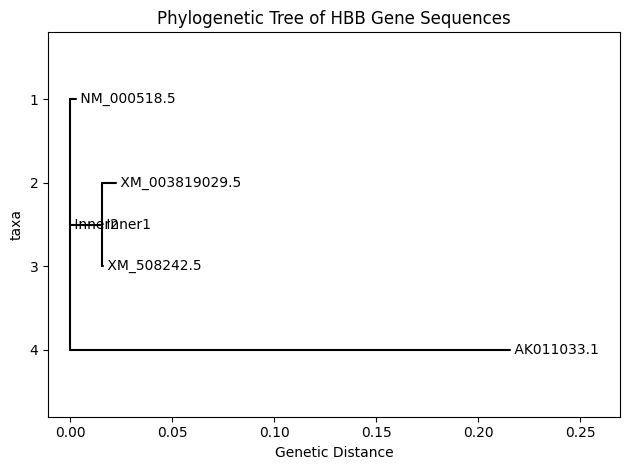

In [13]:
from Bio import Phylo
import matplotlib.pyplot as plt

# Make figure bigger
plt.figure(figsize=(10, 6))

# Draw tree
Phylo.draw(
    tree,
    do_show=False
)

plt.title("Phylogenetic Tree of HBB Gene Sequences")
plt.xlabel("Genetic Distance")
plt.tight_layout()

# Save beautiful tree image
plt.savefig("hbb_phylogenetic_tree.png", dpi=300)

plt.show()

<Figure size 1000x600 with 0 Axes>

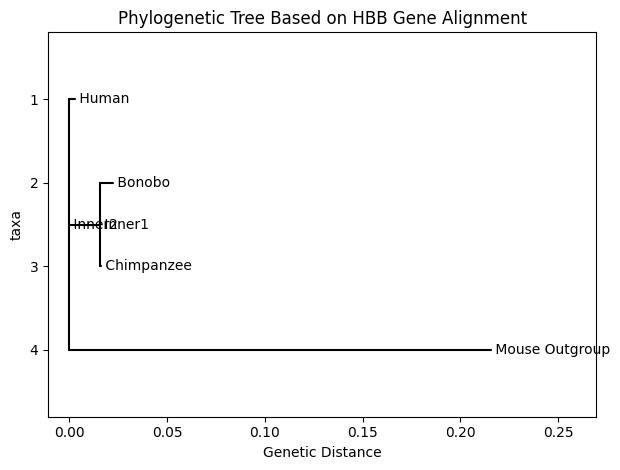

In [14]:
# Rename labels before drawing
for clade in tree.find_clades():
    if clade.name == "NM_000518.5":
        clade.name = "Human"
    elif clade.name == "XM_508242.5":
        clade.name = "Chimpanzee"
    elif clade.name == "XM_003819029.5":
        clade.name = "Bonobo"
    elif clade.name == "AK011033.1":
        clade.name = "Mouse Outgroup"

plt.figure(figsize=(10, 6))
Phylo.draw(tree, do_show=False)
plt.title("Phylogenetic Tree Based on HBB Gene Alignment")
plt.xlabel("Genetic Distance")
plt.tight_layout()
plt.savefig("hbb_phylogenetic_tree_labeled.png", dpi=300)
plt.show()

<Figure size 1000x600 with 0 Axes>

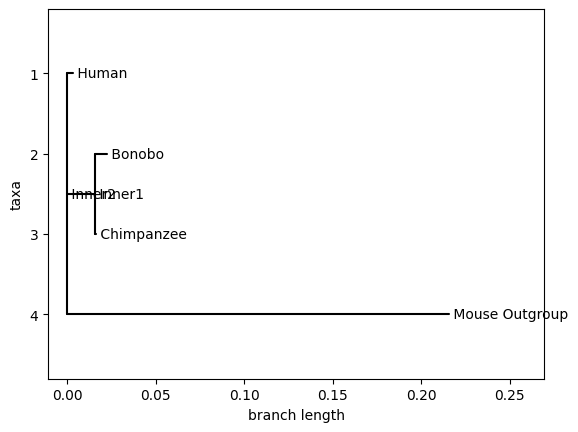

In [15]:
plt.figure(figsize=(10,6))
Phylo.draw(tree, do_show=False)
plt.savefig("phylogenetic_tree.png", dpi=300)
plt.show()

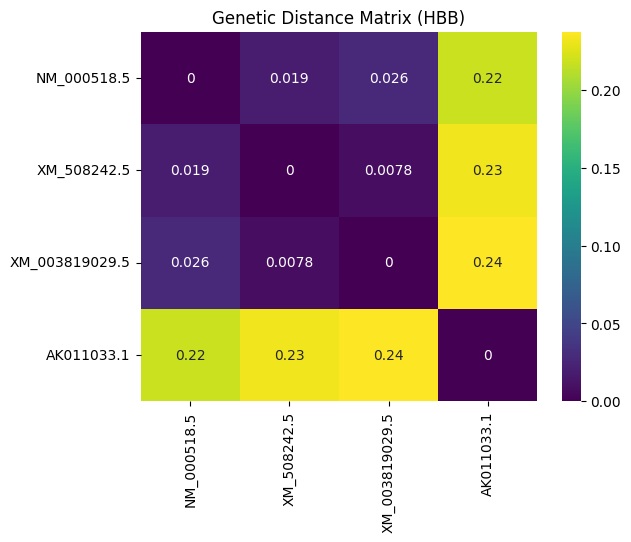

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert distance matrix to DataFrame
names = distance_matrix.names

df = pd.DataFrame(
    distance_matrix.matrix,
    index=names,
    columns=names[:len(distance_matrix.matrix)]
)

# Fix lower-triangular matrix to full matrix
for i in range(len(df)):
    for j in range(i):
        df.iloc[j, i] = df.iloc[i, j]

sns.heatmap(df, annot=True, cmap="viridis")
plt.title("Genetic Distance Matrix (HBB)")
plt.show()

In [17]:
import sys
!{sys.executable} -m pip install scipy

  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 15.1 MB/s  0:00:02 eta 0:00:010:01:01
